In [193]:
from ax.service.ax_client import AxClient
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import ax
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
import matplotlib.cm as cm


import sys
sys.path.append('20250708-ibp/')
import helper_functions as hf

In [194]:
n = 15

ax_client_file_path = f"20250708-ibp/iteration_{n}/optimizer/optimizer_{n}_loaded.json"

In [195]:
ax_client = AxClient.load_from_json_file(ax_client_file_path)


In [196]:
df = ax_client.get_trials_data_frame()
df

,trial_index,arm_name,trial_status,generation_node,success,surfactant_input,complexity,Drug_MW,Drug_LogP,Drug_TPSA,s1,s2,s3,s4,s5,s6,s7,s8,surfactant_conc,drug_conc
0,0,0_0,COMPLETED,GenerationStep_0,0.0,1.00,1.000,0.206,0.307,0.037,47,60,50,31,96,8,9,35,85,100
1,1,1_0,COMPLETED,GenerationStep_0,0.0,1.00,1.000,0.206,0.307,0.037,74,0,88,66,22,52,58,79,35,100
2,2,2_0,COMPLETED,GenerationStep_0,0.0,1.00,1.000,0.206,0.307,0.037,78,88,1,3,32,94,44,58,1,100
3,3,3_0,COMPLETED,GenerationStep_1,1.0,1.00,0.625,0.206,0.307,0.037,0,100,100,100,0,100,100,0,100,100
4,4,4_0,COMPLETED,GenerationStep_1,1.0,1.00,0.250,0.206,0.307,0.037,0,0,0,100,0,0,100,0,100,100
5,5,5_0,COMPLETED,GenerationStep_1,0.0,1.00,1.000,0.206,0.307,0.037,100,0,0,100,100,0,100,0,1,100
6,6,6_0,COMPLETED,GenerationStep_1,1.0,1.00,0.250,0.206,0.307,0.037,0,0,100,0,0,0,100,0,100,100
7,7,7_0,COMPLETED,GenerationStep_1,1.0,1.00,0.500,0.206,0.307,0.037,0,100,0,100,0,0,100,100,100,100
8,8,8_0,COMPLETED,GenerationStep_1,1.0,1.00,0.250,0.206,0.307,0.037,0,0,0,100,0,100,0,0,100,100
9,9,9_0,COMPLETED,GenerationStep_1,0.0,1.00,1.000,0.206,0.307,0.037,0,0,100,100,0,0,0,0,1,100


In [197]:
batch_size = 3

num_batches = len(df)/batch_size  # how many different numbers you want

iteration_array = np.repeat(np.arange(num_batches), batch_size)
df['Iteration'] = iteration_array


iteration_array

array([ 0.,  0.,  0.,  1.,  1.,  1.,  2.,  2.,  2.,  3.,  3.,  3.,  4.,
        4.,  4.,  5.,  5.,  5.,  6.,  6.,  6.,  7.,  7.,  7.,  8.,  8.,
        8.,  9.,  9.,  9., 10., 10., 10., 11., 11., 11., 12., 12., 12.,
       13., 13., 13., 14., 14., 14., 15., 15., 15.])

In [198]:
params = ['s1', 's2', 's3', 's4', 's5', 's6', 's7', 's8', 'surfactant_conc', 'drug_conc']

objs = ['complexity', 'success', 'surfactant_input']

In [199]:
cols_to_keep = ['trial_index', 'Iteration', 'success', 'complexity', 'Drug_MW',	'Drug_LogP', 'Drug_TPSA', 'surfactant_input']


processed_df = hf.design_to_conc(df)
processed_df[cols_to_keep] = df[cols_to_keep]

processed_df['Iteration'] = processed_df['Iteration'].astype(int)
processed_df['surfactant_conc'] = processed_df['surfactant_conc']/50
processed_df

,trial_index,surfactant_conc,drug_conc,s1,s2,s3,s4,s5,s6,s7,s8,Iteration,success,complexity,Drug_MW,Drug_LogP,Drug_TPSA,surfactant_input
0,0,0.85,25.0,5.944940,7.589286,6.324405,3.921131,12.142857,1.011905,1.138393,4.427083,0,0.0,1.000,0.206,0.307,0.037,1.00
1,1,0.35,25.0,2.949886,0.000000,3.507973,2.630979,0.876993,2.072893,2.312073,3.149203,0,0.0,1.000,0.206,0.307,0.037,1.00
2,2,0.01,25.0,0.097990,0.110553,0.001256,0.003769,0.040201,0.118090,0.055276,0.072864,0,0.0,1.000,0.206,0.307,0.037,1.00
3,3,1.00,25.0,0.000000,10.000000,10.000000,10.000000,0.000000,10.000000,10.000000,0.000000,1,1.0,0.625,0.206,0.307,0.037,1.00
4,4,1.00,25.0,0.000000,0.000000,0.000000,25.000000,0.000000,0.000000,25.000000,0.000000,1,1.0,0.250,0.206,0.307,0.037,1.00
5,5,0.01,25.0,0.125000,0.000000,0.000000,0.125000,0.125000,0.000000,0.125000,0.000000,1,0.0,1.000,0.206,0.307,0.037,1.00
6,6,1.00,25.0,0.000000,0.000000,25.000000,0.000000,0.000000,0.000000,25.000000,0.000000,2,1.0,0.250,0.206,0.307,0.037,1.00
7,7,1.00,25.0,0.000000,12.500000,0.000000,12.500000,0.000000,0.000000,12.500000,12.500000,2,1.0,0.500,0.206,0.307,0.037,1.00
8,8,1.00,25.0,0.000000,0.000000,0.000000,25.000000,0.000000,25.000000,0.000000,0.000000,2,1.0,0.250,0.206,0.307,0.037,1.00
9,9,0.01,25.0,0.000000,0.000000,0.250000,0.250000,0.000000,0.000000,0.000000,0.000000,3,0.0,1.000,0.206,0.307,0.037,1.00


In [200]:
from pymoo.indicators.hv import Hypervolume
from pymoo.util.nds.non_dominated_sorting import NonDominatedSorting


def hv(df_norm):
    
    data = df_norm.copy()


    data['success_min'] = 1-data['success']
    data['complexity_min'] = data['complexity']
    data['surfactant_input_min'] = data['surfactant_input']


    # Select relevant objectives for hypervolume calculation
    objectives = ['success_min',  'surfactant_input_min', 'complexity_min']

    # Define the reference point (worst case + 20%)
    reference_point = [1.2, 1.2, 1.2]

    hv_values = []

    for trial in sorted(data['trial_index']):
        formulation = data[data['trial_index'] == trial][objectives].values
        hv = Hypervolume(ref_point=reference_point)
        hv_values.append(hv.do(formulation))
        hv_values.append(trial)
    
    # Perform non-dominated sorting to determine Pareto front
    nds = NonDominatedSorting()
    pareto_fronts = nds.do(data[objectives].values)
    
    # Create a list to indicate Pareto front membership (1 for Pareto front, 0 otherwise)
    pareto_flags = [1 if i in pareto_fronts[0] else 0 for i in range(len(data))]

    return hv_values[::2], pareto_flags

In [201]:
processed_df['Hypervolume'], processed_df['Pareto'] = hv(processed_df)
processed_df

,trial_index,surfactant_conc,drug_conc,s1,s2,s3,s4,s5,s6,s7,s8,Iteration,success,complexity,Drug_MW,Drug_LogP,Drug_TPSA,surfactant_input,Hypervolume,Pareto
0,0,0.85,25.0,5.944940,7.589286,6.324405,3.921131,12.142857,1.011905,1.138393,4.427083,0,0.0,1.000,0.206,0.307,0.037,1.00,0.0080,0
1,1,0.35,25.0,2.949886,0.000000,3.507973,2.630979,0.876993,2.072893,2.312073,3.149203,0,0.0,1.000,0.206,0.307,0.037,1.00,0.0080,0
2,2,0.01,25.0,0.097990,0.110553,0.001256,0.003769,0.040201,0.118090,0.055276,0.072864,0,0.0,1.000,0.206,0.307,0.037,1.00,0.0080,0
3,3,1.00,25.0,0.000000,10.000000,10.000000,10.000000,0.000000,10.000000,10.000000,0.000000,1,1.0,0.625,0.206,0.307,0.037,1.00,0.1380,0
4,4,1.00,25.0,0.000000,0.000000,0.000000,25.000000,0.000000,0.000000,25.000000,0.000000,1,1.0,0.250,0.206,0.307,0.037,1.00,0.2280,0
5,5,0.01,25.0,0.125000,0.000000,0.000000,0.125000,0.125000,0.000000,0.125000,0.000000,1,0.0,1.000,0.206,0.307,0.037,1.00,0.0080,0
6,6,1.00,25.0,0.000000,0.000000,25.000000,0.000000,0.000000,0.000000,25.000000,0.000000,2,1.0,0.250,0.206,0.307,0.037,1.00,0.2280,0
7,7,1.00,25.0,0.000000,12.500000,0.000000,12.500000,0.000000,0.000000,12.500000,12.500000,2,1.0,0.500,0.206,0.307,0.037,1.00,0.1680,0
8,8,1.00,25.0,0.000000,0.000000,0.000000,25.000000,0.000000,25.000000,0.000000,0.000000,2,1.0,0.250,0.206,0.307,0.037,1.00,0.2280,0
9,9,0.01,25.0,0.000000,0.000000,0.250000,0.250000,0.000000,0.000000,0.000000,0.000000,3,0.0,1.000,0.206,0.307,0.037,1.00,0.0080,0


In [202]:
def boxplot(data, col, ax, ann):
    fontsize = 12
    # Ensure 'iteration' is treated as a categorical variable
    data['iteration'] = data['iteration'].astype(str)
    
    # Generate a color palette with increasing darkness from iteration 0 to max iteration
    unique_iterations = sorted(data['iteration'].unique(), key=int)  # Sort as integers
    num_iterations = len(unique_iterations)
    colors = sns.color_palette("BuPu", num_iterations)  # Using Blues colormap for gradient effect
    color_map = {str(iteration): colors[i] for i, iteration in enumerate(unique_iterations)}  # Ensure keys are strings
    
    # Create the boxplot with specific styling
    sns.boxplot(
        x=data['iteration'], 
        y=data[col], 
        #color = '#f5d7e5', 
        palette=color_map,  # Apply the color mapping
        linewidth=0.5,  # Set border width
        boxprops={'edgecolor': 'black'},  # Set border color
        whiskerprops={'color': 'black'},
        capprops={'color': 'black'},
        medianprops={'color': 'black'},
        showfliers=False,  # Hide outlier circles
        ax=ax  # Use the provided axis
    )
    
    # Add jittered scatter points with transparent fill and black edge
    for i, iteration in enumerate(unique_iterations):
        subset = data[data['iteration'] == iteration]
        x_jittered = np.random.normal(loc=i, scale=0.1, size=len(subset))  # Adding jitter
        ax.scatter(x_jittered, subset[col], color='none', edgecolors='black', alpha=0.5, zorder=3)  # Bring scatters to front
    
    # Adjust font sizes
    ax.set_xlabel('Iteration', fontsize=fontsize)
    ax.set_ylabel(col, fontsize=fontsize)
    ax.set_xticklabels(ax.get_xticks(), fontsize=fontsize)

    # Format y-axis ticks to show fewer decimals
    if (col == 'Size' or col == 'Complexity'):
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}'))
        ax.set_yticklabels([f'{tick:.0f}' for tick in ax.get_yticks()], fontsize=fontsize)
    else:
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.2f}'))
        ax.set_yticklabels([f'{tick:.2f}' for tick in ax.get_yticks()], fontsize=fontsize)


    ax.annotate(ann, xy=(0, 1.08), xycoords="axes fraction", va="top", ha="left", fontsize=fontsize)

    #ax.set_title(f'Convergence for {col}')

In [203]:
processed_df['Iteration'] = processed_df['Iteration'].astype(int)
processed_df['iteration'] = processed_df['Iteration'].astype(int)

In [204]:
def traceplot(data, col, ax, ann, minimize=True):
    fontsize = 12

    # Ensure 'iteration' is integer
    data['Iteration'] = data['Iteration'].astype(int)
    data['iteration'] = data['Iteration']

    # Group by iteration and get best (min or max) value
    grouped = data.groupby('iteration')[col]
    if minimize:
        best_per_iter = grouped.min()
    else:
        best_per_iter = grouped.max()

    # Compute best-so-far trace
    best_so_far = []
    current_best = None
    for val in best_per_iter:
        if current_best is None:
            current_best = val
        else:
            current_best = min(current_best, val) if minimize else max(current_best, val)
        best_so_far.append(current_best)

    iterations = best_per_iter.index.to_numpy()
    best_so_far = np.array(best_so_far)

    # Generate gradient colors
    num_iterations = len(iterations)
    colors = sns.color_palette("BuPu", num_iterations)

    # Fill between each pair of points
    for i in range(1, len(iterations)):
        x = [iterations[i-1], iterations[i]]
        y1 = [best_so_far[i-1], best_so_far[i]]
        ax.fill_between(x, [0, 0], y1, color=colors[i-1], alpha=0.6, zorder=1)

    # Plot the trace line and points
    ax.plot(iterations, best_so_far, color=colors[num_iterations-1], linewidth=2, zorder=3)
    ax.scatter(iterations, best_so_far, color=colors[num_iterations-1], s=10, zorder=4)

    # Styling
    ax.set_xlabel('Iteration', fontsize=fontsize)
    ax.set_ylabel(col, fontsize=fontsize)
    ax.tick_params(labelsize=fontsize)

    if col in ['Size', 'Complexity']:
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}'))
    else:
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.2f}'))

    ax.annotate(ann, xy=(0, 1.08), xycoords="axes fraction", va="top", ha="left", fontsize=fontsize)
    ax.set_facecolor('none')

C:\Users\yunhe\AppData\Local\Temp\ipykernel_16460\1445016178.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\yunhe\AppData\Local\Temp\ipykernel_16460\1445016178.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticks(), fontsize=fontsize)
C:\Users\yunhe\AppData\Local\Temp\ipykernel_16460\1445016178.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f'{tick:.2f}' for tick in ax.get_yticks()], fontsize=fontsize)
C:\Users\yunhe\AppData\Local\Temp\ipykernel_16460\1445016178.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to 

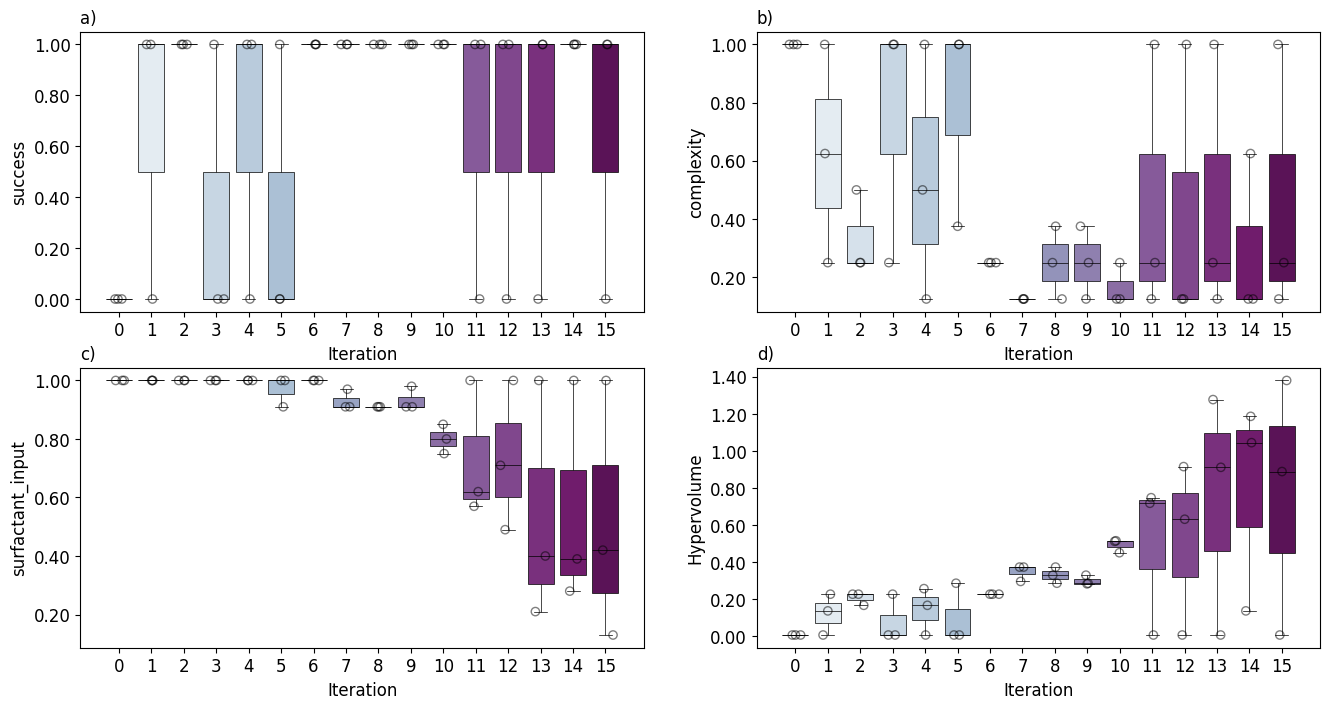

In [205]:
# plot optimization process as boxplots (formulation quality = 1)

fig = plt.figure(figsize=(16, 8))
grid = plt.GridSpec(2, 2, wspace=0.2, hspace=0.2)

data_to_plot = processed_df.copy()

ax1 = fig.add_subplot(grid[0, 0])
boxplot(data_to_plot, 'success', ax1, 'a)')

ax2 = fig.add_subplot(grid[0, 1])
boxplot(data_to_plot, 'complexity', ax2, 'b)')

ax3 = fig.add_subplot(grid[1, 0])
boxplot(data_to_plot, 'surfactant_input', ax3, 'c)')

ax4 = fig.add_subplot(grid[1, 1])
boxplot(data_to_plot, 'Hypervolume', ax4, 'd)')


fig.patch.set(facecolor='none')
fig.canvas.print_figure('Boxplot.png', dpi=600)
plt.show()

C:\Users\yunhe\AppData\Local\Temp\ipykernel_16460\1445016178.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\yunhe\AppData\Local\Temp\ipykernel_16460\1445016178.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticks(), fontsize=fontsize)
C:\Users\yunhe\AppData\Local\Temp\ipykernel_16460\1445016178.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f'{tick:.2f}' for tick in ax.get_yticks()], fontsize=fontsize)


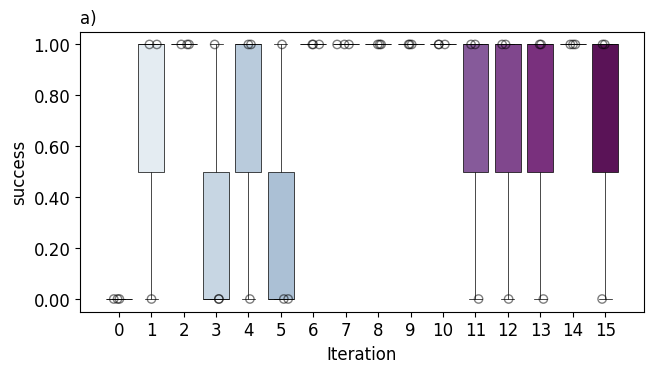

In [206]:

fig = plt.figure(figsize=(16, 8))
grid = plt.GridSpec(2, 2, wspace=0.2, hspace=0.2)

data_to_plot = processed_df.copy()


ax1 = fig.add_subplot(grid[0, 0])
boxplot(data_to_plot, 'success', ax1, 'a)')



#fig.canvas.print_figure('Boxplot.png', dpi=600)

fig.patch.set(facecolor='none')
fig.canvas.print_figure('Boxplot_success.png', dpi=600)
plt.show()

C:\Users\yunhe\AppData\Local\Temp\ipykernel_16460\1445016178.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\yunhe\AppData\Local\Temp\ipykernel_16460\1445016178.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticks(), fontsize=fontsize)
C:\Users\yunhe\AppData\Local\Temp\ipykernel_16460\1445016178.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f'{tick:.2f}' for tick in ax.get_yticks()], fontsize=fontsize)


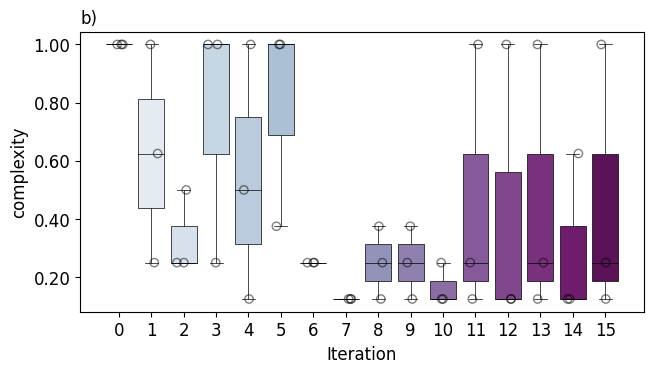

In [207]:
# plot optimization process as boxplots (formulation quality = 1)

fig = plt.figure(figsize=(16, 8))
grid = plt.GridSpec(2, 2, wspace=0.2, hspace=0.2)

data_to_plot = processed_df.copy()


ax2 = fig.add_subplot(grid[0, 1])
boxplot(data_to_plot, 'complexity', ax2, 'b)')


#fig.canvas.print_figure('Boxplot.png', dpi=600)

fig.patch.set(facecolor='none')
fig.canvas.print_figure('Boxplot_complexity.png', dpi=600)
plt.show()

C:\Users\yunhe\AppData\Local\Temp\ipykernel_16460\1445016178.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\yunhe\AppData\Local\Temp\ipykernel_16460\1445016178.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticks(), fontsize=fontsize)
C:\Users\yunhe\AppData\Local\Temp\ipykernel_16460\1445016178.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f'{tick:.2f}' for tick in ax.get_yticks()], fontsize=fontsize)


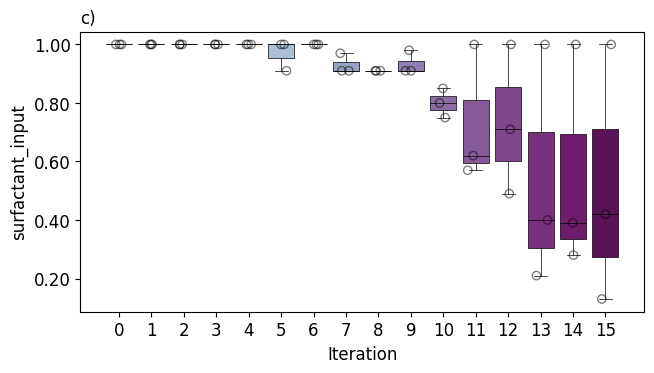

In [208]:
fig = plt.figure(figsize=(16, 8))
grid = plt.GridSpec(2, 2, wspace=0.2, hspace=0.2)

data_to_plot = processed_df.copy()


ax3 = fig.add_subplot(grid[1, 0])
boxplot(data_to_plot, 'surfactant_input', ax3, 'c)')


#fig.canvas.print_figure('Boxplot.png', dpi=600)

fig.patch.set(facecolor='none')
fig.canvas.print_figure('Boxplot_surfactant_input.png', dpi=600)
plt.show()

C:\Users\yunhe\AppData\Local\Temp\ipykernel_16460\1445016178.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\yunhe\AppData\Local\Temp\ipykernel_16460\1445016178.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticks(), fontsize=fontsize)
C:\Users\yunhe\AppData\Local\Temp\ipykernel_16460\1445016178.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f'{tick:.2f}' for tick in ax.get_yticks()], fontsize=fontsize)


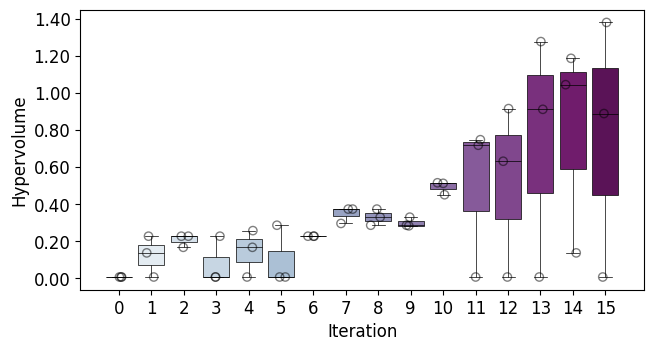

In [209]:
fig = plt.figure(figsize=(16, 8))
grid = plt.GridSpec(2, 2, wspace=0.2, hspace=0.2)


data_to_plot = processed_df.copy()



ax4 = fig.add_subplot(grid[1, 1])
boxplot(data_to_plot, 'Hypervolume', ax4,"")


fig.patch.set(facecolor='none')
fig.canvas.print_figure('Boxplot_Hypervolume.png', dpi=600)
plt.show()

C:\Users\yunhe\AppData\Local\Temp\ipykernel_16460\4197288805.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\yunhe\AppData\Local\Temp\ipykernel_16460\4197288805.py:125: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


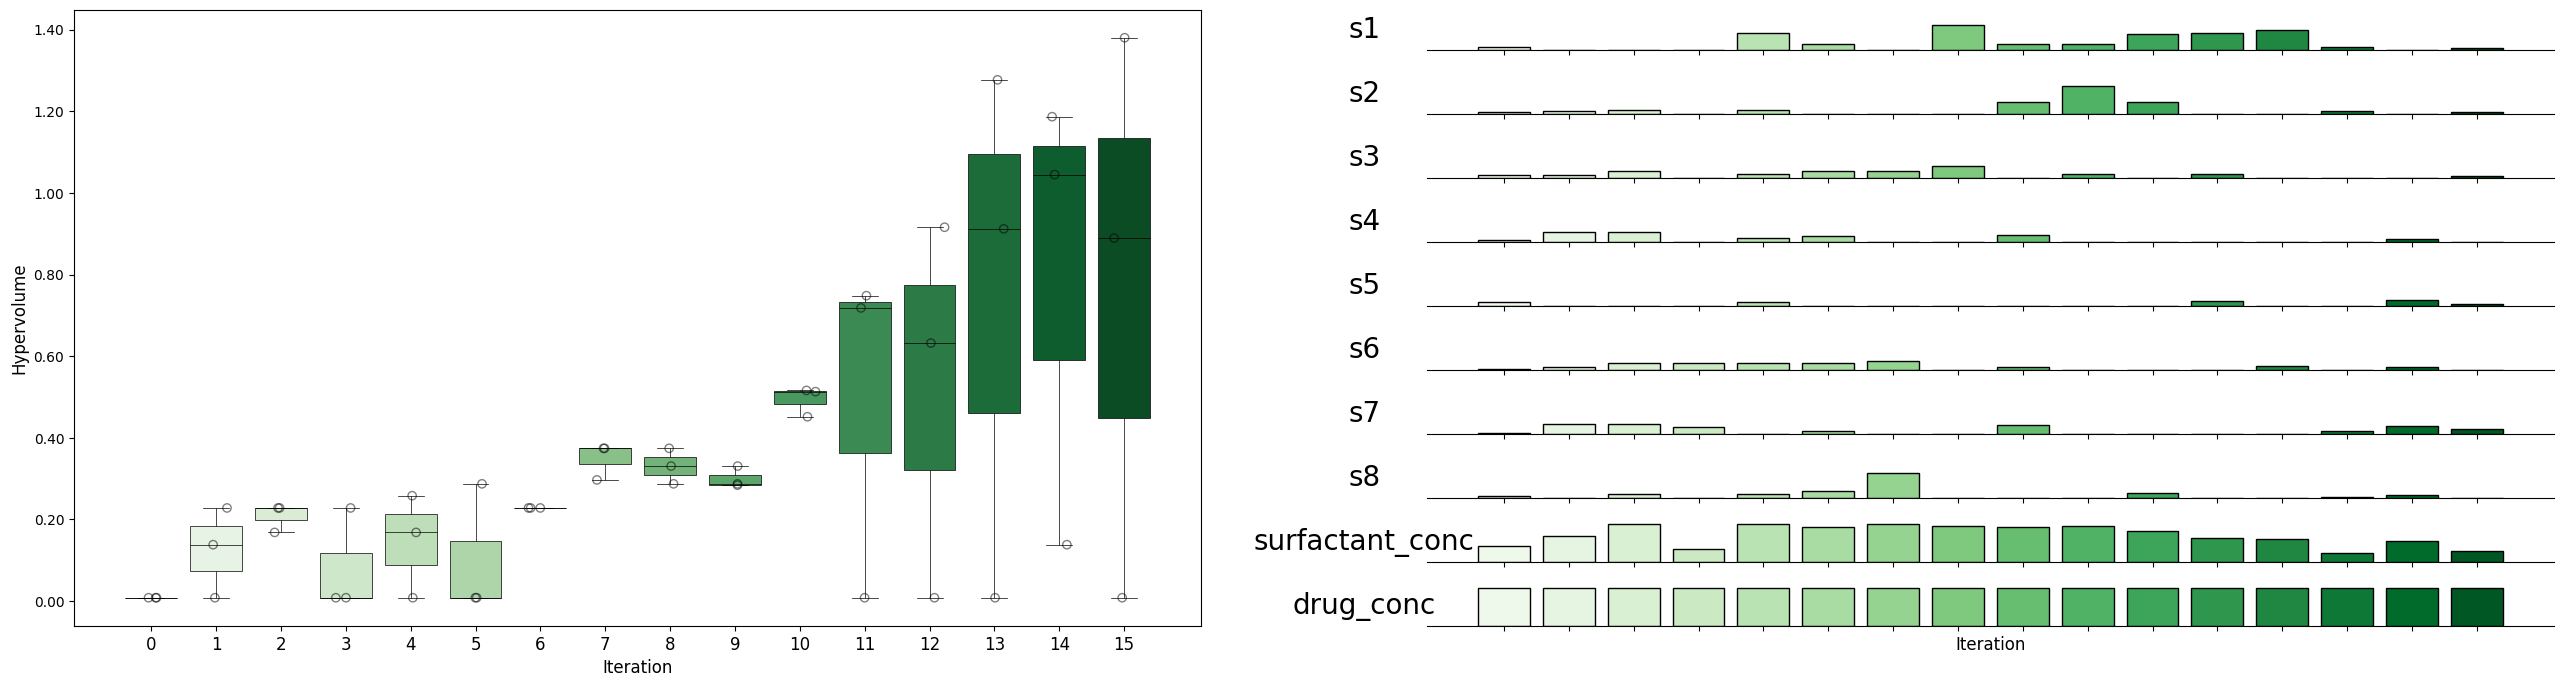

In [210]:
def boxplot(data, col, ax, ann):
    fontsize = 12
    data = data.copy()
    data['iteration'] = data['iteration'].astype(int)
    iterations = sorted(data['iteration'].unique())
    colors = sns.color_palette("Greens", len(iterations)) #color

    sns.boxplot(
        x='iteration', y=col, data=data,
        order=iterations, palette=colors,
        linewidth=0.5,
        boxprops={'edgecolor':'black'},
        whiskerprops={'color':'black'},
        capprops={'color':'black'},
        medianprops={'color':'black'},
        showfliers=False,
        ax=ax
    )
    for it in iterations:
        sub = data[data['iteration']==it]
        xj = np.random.normal(it, 0.1, size=len(sub))
        ax.scatter(xj, sub[col], facecolors='none',
                   edgecolors='black', alpha=0.5, zorder=3)

    ax.set_ylabel(col, fontsize=fontsize)
    ax.set_xticks(iterations)
    ax.set_xticklabels(iterations, fontsize=fontsize)

    ax.set_xlabel("Iteration", fontsize=fontsize)

    fmt = mticker.FuncFormatter(
        lambda x, _: f'{x:.0f}' if col in ('Size','Complexity') else f'{x:.2f}'
    )
    ax.yaxis.set_major_formatter(fmt)
    ax.annotate(ann, xy=(0,1.08), xycoords='axes fraction',
                ha='left', va='top', fontsize=fontsize)


def bar(data, param, ax, ann=None):
    import seaborn as sns
    fontsize = 20
    data = data.copy()
    data['iteration'] = data['iteration'].astype(int)
    iterations = sorted(data['iteration'].unique())
    means = data.groupby('iteration')[param].mean().reindex(iterations)

    # exactly the same palette as your boxplot
    colors = sns.color_palette("Greens", len(iterations))

    # draw bars, one color per iteration
    ax.bar(
        iterations,
        means,
        width=0.8,
        color=colors,
        edgecolor='black'
    )

    # horizontal y-label on left
    ax.set_ylabel(param,
                  fontsize=fontsize,
                  rotation=0,
                  labelpad=45,
                  va='center')

    if ann:
        ax.annotate(ann,
                    xy=(0,1.08),
                    xycoords='axes fraction',
                    ha='left', va='top',
                    fontsize=fontsize)

    # fix y-limits for s1–s8
    if param in [f's{i}' for i in range(1,9)]:
        ax.set_ylim(0, 50)

    # strip all but bottom spine
    for loc in ('top','right','left'):
        ax.spines[loc].set_visible(False)
    ax.spines['bottom'].set_visible(True)

    # only bottom ticks, no labels
    ax.xaxis.set_ticks_position('bottom')
    ax.tick_params(
        axis='x',
        which='both',
        bottom=True,
        labelbottom=False,
        labelsize=fontsize
    )
    ax.tick_params(
        axis='y',
        which='both',
        left=False,
        labelleft=False
    )


# --- build the stacked figure with bars ---

boxplot_rows = len(params)
params = ['s1','s2','s3','s4','s5','s6','s7','s8','surfactant_conc','drug_conc']
data = processed_df.copy()
total_rows = len(params)

#fig = plt.figure(figsize=(20, total_rows * 1))
fig = plt.figure(figsize=(32,8))
gs = fig.add_gridspec(nrows=total_rows, ncols=2, hspace=0.6)

# Boxplot at top
ax0 = fig.add_subplot(gs[0:boxplot_rows, 0])
boxplot(data, 'Hypervolume', ax0, ann=None)

# Bars for each parameter
for i, param in enumerate(params):
#    row = boxplot_rows + i
    ax = fig.add_subplot(gs[i, 1], sharex=ax0)
    bar(data, param, ax, ann=None)

# label only the bottommost x-axis
fig.axes[-1].set_xlabel('Iteration', fontsize=12)

fig.canvas.print_figure('hypervolume.png', dpi=600)

plt.tight_layout()
plt.show()


C:\Users\yunhe\AppData\Local\Temp\ipykernel_16460\1487582475.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\yunhe\AppData\Local\Temp\ipykernel_16460\1487582475.py:127: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


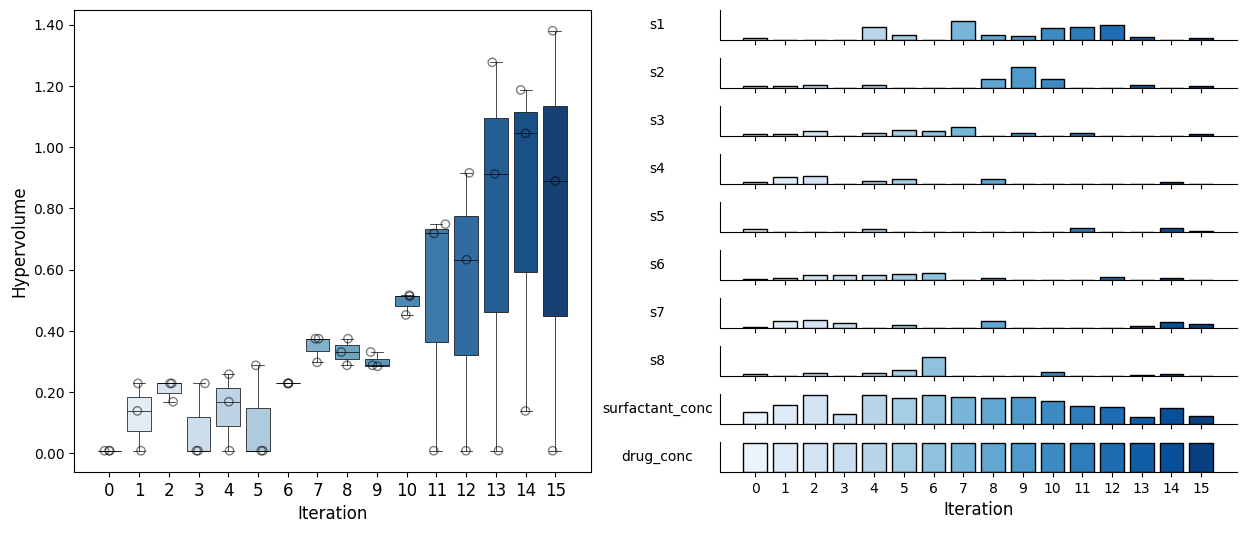

In [211]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.ticker as mticker

def boxplot(data, col, ax, ann):
    fontsize = 12
    data = data.copy()
    data['iteration'] = data['iteration'].astype(int)
    iterations = sorted(data['iteration'].unique())
    colors = sns.color_palette("Blues", len(iterations))

    sns.boxplot(
        x='iteration', y=col, data=data,
        order=iterations, palette=colors,
        linewidth=0.5,
        boxprops={'edgecolor':'black'},
        whiskerprops={'color':'black'},
        capprops={'color':'black'},
        medianprops={'color':'black'},
        showfliers=False,
        ax=ax
    )
    for it in iterations:
        sub = data[data['iteration']==it]
        xj = np.random.normal(it, 0.1, size=len(sub))
        ax.scatter(xj, sub[col], facecolors='none',
                   edgecolors='black', alpha=0.5, zorder=3)

    ax.set_ylabel(col, fontsize=fontsize)
    ax.set_xticks(iterations)
    ax.set_xticklabels(iterations, fontsize=fontsize)
    ax.set_xlabel("Iteration", fontsize=fontsize)

    fmt = mticker.FuncFormatter(
        lambda x, _: f'{x:.0f}' if col in ('Size','Complexity') else f'{x:.2f}'
    )
    ax.yaxis.set_major_formatter(fmt)
    ax.annotate(ann, xy=(0,1.08), xycoords='axes fraction',
                ha='left', va='top', fontsize=fontsize)

# --- modified bar function with y-axis spine and label visible ---
def bar(data, param, ax, ann=None):
    fontsize = 10
    data = data.copy()
    data['iteration'] = data['iteration'].astype(int)
    iterations = sorted(data['iteration'].unique())
    means = data.groupby('iteration')[param].mean().reindex(iterations)

    # same palette
    colors = sns.color_palette("Blues", len(iterations))

    # draw bars
    ax.bar(
        iterations,
        means,
        width=0.8,
        color=colors,
        edgecolor='black'
    )

    # show y-axis label
    ax.set_ylabel(param,
                  fontsize=fontsize,
                  rotation=0,
                  labelpad=45,
                  va='center')

    if ann:
        ax.annotate(ann,
                    xy=(0,1.08),
                    xycoords='axes fraction',
                    ha='left', va='top',
                    fontsize=fontsize)

    # fixed limits for s1–s8
    if param in [f's{i}' for i in range(1,9)]:
        ax.set_ylim(0, 50)

    # strip top and right spines only
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    # ensure left spine is visible
    ax.spines['left'].set_visible(True)
    ax.spines['bottom'].set_visible(True)

    # only bottom ticks, no x tick labels by default
    ax.xaxis.set_ticks_position('bottom')
    ax.tick_params(
        axis='x',
        which='both',
        bottom=True,
        labelbottom=False,
        labelsize=fontsize
    )
    # hide y ticks but keep axis line
    ax.tick_params(
        axis='y',
        which='both',
        left=False,
        labelleft=False
    )

# --- build the stacked figure with bars ---
params = ['s1','s2','s3','s4','s5','s6','s7','s8','surfactant_conc','drug_conc']
fig = plt.figure(figsize=(15, len(params) * 0.6))
boxplot_rows = len(params)
gs = fig.add_gridspec(nrows=len(params), ncols=2, hspace=0.6, wspace=0.25)

# Boxplot at top
ax0 = fig.add_subplot(gs[0:boxplot_rows, 0])
boxplot(processed_df.copy(), 'Hypervolume', ax0, ann=None)

# Bars for each parameter
for i, param in enumerate(params):
    ax = fig.add_subplot(gs[i, 1], sharex=ax0)
    bar(processed_df.copy(), param, ax, ann=None)

# label and show tick labels only on the bottommost bar chart
last_ax = fig.axes[-1]
last_ax.set_xlabel('Iteration', fontsize=12)
last_ax.tick_params(axis='x', which='both', labelbottom=True)

# Save the figure
fig.patch.set(facecolor='none')
fig.canvas.print_figure('hypervolume_2.png', dpi=600)
plt.tight_layout()
plt.show()
